In [60]:
import pandas as pd
import torch
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error

In [59]:
import uni2ts
print(uni2ts.__version__)

2.0.0


In [18]:
df = pd.read_csv("../data/processed/monthly_labor_market.csv")

df.rename(columns={"date": "ds"}, inplace=True)
df["ds"] = pd.to_datetime(df["ds"], format="%Y:%m")

df = df.dropna(how="all", subset=df.columns[1:])
df = df.ffill()
df = df.dropna()

df.head()

,ds,POP,LFC,LFPART,RUC,EMPLOY,H,HG,HS
300,1964-01-01,123560.0,72356.0,58.5594,5.6,57487.0,50.8,92.4,39.3
301,1964-02-01,123707.0,72683.0,58.7542,5.4,57753.0,51.5,95.3,39.4
302,1964-03-01,123857.0,72713.0,58.7072,5.4,57897.0,51.5,95.1,39.4
303,1964-04-01,124019.0,73274.0,59.0829,5.3,57922.0,51.7,95.2,39.6
304,1964-05-01,124204.0,73395.0,59.0923,5.1,58089.0,51.9,95.6,39.6


In [19]:
TARGET = "EMPLOY"

In [20]:
split = int(len(df) * 0.8)

train_df = df.iloc[:split]
test_df = df.iloc[split:split+12]

y_true = test_df[TARGET].values

In [32]:
from chronos import ChronosPipeline
import torch

# convert series
series = torch.tensor(train_df[TARGET].values, dtype=torch.float32)

# load model
pipeline = ChronosPipeline.from_pretrained("amazon/chronos-t5-small")

# generate forecast (num_samples x prediction_length)
forecast = pipeline.predict(
    series,
    prediction_length=12,
    num_samples=20
)

# STEP 1: average across samples → should become (12,)
chronos_pred = forecast.mean(dim=0)

# STEP 2: if still 2D, fix it
if len(chronos_pred.shape) > 1:
    chronos_pred = chronos_pred[0]

# STEP 3: convert to numpy (NO flatten)
chronos_pred = chronos_pred.detach().cpu().numpy()

# STEP 4: verify
print("Shape:", chronos_pred.shape)
print("Prediction:", chronos_pred)

Shape: (12,)
Prediction: [137325.2  137325.2  137325.2  137325.2  138128.28 138128.28 138128.28
 138128.28 138128.28 138128.28 138128.28 138128.28]


In [34]:

mae = mean_absolute_error(y_true, chronos_pred)
print("Chronos MAE:", mae)

Chronos MAE: 444.1536458333333


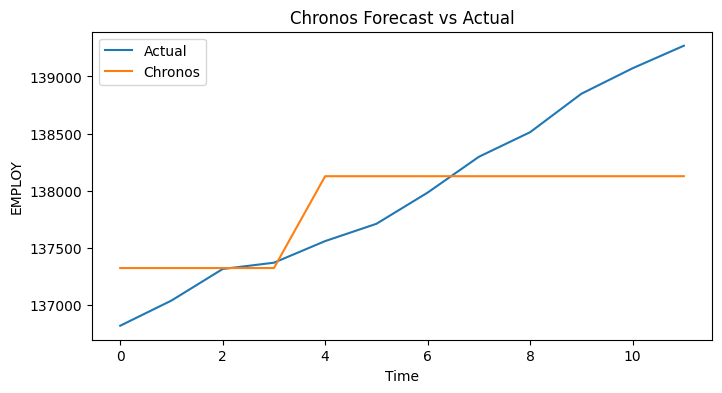

In [36]:


plt.figure(figsize=(8,4))

plt.plot(range(len(y_true)), y_true, label="Actual")
plt.plot(range(len(chronos_pred)), chronos_pred, label="Chronos")

plt.legend()
plt.title("Chronos Forecast vs Actual")
plt.xlabel("Time")
plt.ylabel(TARGET)

plt.show()

In [37]:
print("Train shape:", train_df.shape)
print("Test shape:", test_df.shape)

Train shape: (596, 9)
Test shape: (12, 9)


In [38]:
df_nf = train_df[["ds", TARGET]].copy()

df_nf["unique_id"] = "ts1"
df_nf.rename(columns={TARGET: "y"}, inplace=True)

df_nf.head()

,ds,y,unique_id
300,1964-01-01,57487.0,ts1
301,1964-02-01,57753.0,ts1
302,1964-03-01,57897.0,ts1
303,1964-04-01,57922.0,ts1
304,1964-05-01,58089.0,ts1


In [42]:
from neuralforecast import NeuralForecast
from neuralforecast.models import NBEATS

model = NBEATS(
    input_size=36,
    h=12,
    max_steps=300
)

nf = NeuralForecast(models=[model], freq="ME")

nf.fit(df_nf)

Seed set to 1
GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.

  | Name         | Type          | Params | Mode  | FLOPs
---------------------------------------------------------------
0 | loss         | MAE           | 0      | train | 0    
1 | padder_train | ConstantPad1d | 0      | train | 0    
2 | scaler       | TemporalNorm  | 0      | train | 0    
3 | blocks       | ModuleList    | 2.5 M  | train | 0    
---------------------------------------------------------------
2.5 M     Trainable params
1.2 K     Non-trainable params
2.5 M     Total params
9.889     Total estimated model params size (MB)
31        Modules in train mode
0         Modules in eval mode
0         Total Flops


Sanity Checking: |          | 0/? [00:00<?, ?it/s]

/Users/arsheyagourav/Desktop/VIP/macro-ts-datasets/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 34.65it/s, v_num=1, train_loss_step=731.0, train_loss_epoch=731.0]   

`Trainer.fit` stopped: `max_steps=300` reached.


Epoch 299: 100%|██████████| 1/1 [00:00<00:00, 31.88it/s, v_num=1, train_loss_step=731.0, train_loss_epoch=731.0]


In [43]:
forecast = nf.predict()

nbeats_pred = forecast["NBEATS"].values[-12:]

print("Shape:", nbeats_pred.shape)
print("Prediction:", nbeats_pred)

GPU available: True (mps), used: True
TPU available: False, using: 0 TPU cores
💡 Tip: For seamless cloud logging and experiment tracking, try installing [litlogger](https://pypi.org/project/litlogger/) to enable LitLogger, which logs metrics and artifacts automatically to the Lightning Experiments platform.
/Users/arsheyagourav/Desktop/VIP/macro-ts-datasets/.venv/lib/python3.12/site-packages/pytorch_lightning/utilities/_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.


Predicting DataLoader 0: 100%|██████████| 1/1 [00:03<00:00,  0.29it/s]
Shape: (12,)
Prediction: [136952.58 137217.12 137367.47 137551.61 137827.9  137965.25 138167.86
 138400.62 138609.38 138740.7  139000.72 139166.52]


In [44]:
mae_nbeats = mean_absolute_error(y_true, nbeats_pred)
print("N-BEATS MAE:", mae_nbeats)

N-BEATS MAE: 143.48828125


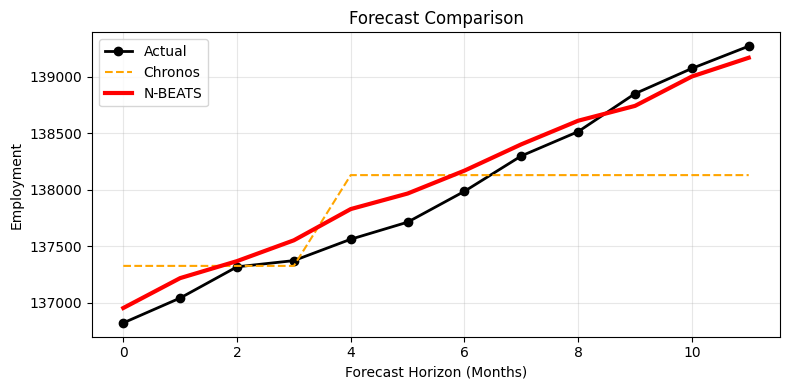

In [51]:
plt.figure(figsize=(8,4))

t = range(12)

plt.plot(t, y_true,
         color="black",
         marker="o",
         label="Actual",
         linewidth=2)

plt.plot(t, chronos_pred,
         linestyle="--",
         color="orange",
         label="Chronos")

plt.plot(t, nbeats_pred,
         color="red",
         label="N-BEATS",
         linewidth=3)

plt.legend()
plt.title("Forecast Comparison")
plt.xlabel("Forecast Horizon (Months)")
plt.ylabel("Employment")

plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

In [56]:
series = train_df[TARGET].values.astype(float)
model = MoiraiForecast.from_pretrained("Salesforce/moirai-1.0-R-small")

AttributeError: type object 'MoiraiForecast' has no attribute 'from_pretrained'